In [1]:
#Step1: Importing all required libraries

import ast  #Abstract Syntax Trees
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first' , dtype=np.int32)


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error    #used when we have numerical item and error wala tell for how much our model prediction is off
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor  #Because it has "Regressor" in the name, 
# it is specifically designed to output that exact, infinite-possibility dollar amount we are looking for.

In [2]:
df1 = pd.read_csv(r"D:\ML Projects\Project1\Datasets\movies_youtube_sentiments.csv")[['name','genre','year','budget','runtime','gross']]
df2 = pd.read_csv(r"D:\ML Projects\Project1\Datasets\tmdb_5000_movies.csv")[['original_title','genres','release_date','budget','runtime','revenue']]

In [3]:
df1.head(3)

,name,genre,year,budget,runtime,gross
0,Harry Potter and the Goblet of Fire,Adventure,2005,150000000.0,157.0,896678241.0
1,The 40-Year-Old Virgin,Comedy,2005,26000000.0,116.0,177378645.0
2,Memoirs of a Geisha,Drama,2005,85000000.0,145.0,162242962.0


In [4]:
df2.head(3)

,original_title,genres,release_date,budget,runtime,revenue
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2009-12-10,237000000,162.0,2787965087
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",2007-05-19,300000000,169.0,961000000
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2015-10-26,245000000,148.0,880674609


In [5]:
df2.isnull().sum()

original_title    0
genres            0
release_date      1
budget            0
runtime           2
revenue           0
dtype: int64

In [6]:
def myFunc(text):
    genre_list = ast.literal_eval(text)
    if(len(genre_list) == 0):
        return np.nan
    else:
        return genre_list[-1]['name']

In [7]:
df2['genres'] = df2['genres'].apply(myFunc)

In [8]:
df2['genres'].head()

0    Science Fiction
1             Action
2              Crime
3           Thriller
4    Science Fiction
Name: genres, dtype: str

In [9]:
df2.head()

,original_title,genres,release_date,budget,runtime,revenue
0,Avatar,Science Fiction,2009-12-10,237000000,162.0,2787965087
1,Pirates of the Caribbean: At World's End,Action,2007-05-19,300000000,169.0,961000000
2,Spectre,Crime,2015-10-26,245000000,148.0,880674609
3,The Dark Knight Rises,Thriller,2012-07-16,250000000,165.0,1084939099
4,John Carter,Science Fiction,2012-03-07,260000000,132.0,284139100


In [10]:
df2.isnull().sum()

original_title     0
genres            28
release_date       1
budget             0
runtime            2
revenue            0
dtype: int64

In [11]:
df1.head()

,name,genre,year,budget,runtime,gross
0,Harry Potter and the Goblet of Fire,Adventure,2005,150000000.0,157.0,896678241.0
1,The 40-Year-Old Virgin,Comedy,2005,26000000.0,116.0,177378645.0
2,Memoirs of a Geisha,Drama,2005,85000000.0,145.0,162242962.0
3,Pride & Prejudice,Drama,2005,28000000.0,129.0,121616555.0
4,Batman Begins,Action,2005,150000000.0,140.0,373661946.0


In [12]:
df2 = df2.rename(columns={'release_date':'year'})

In [13]:
df2.head()

,original_title,genres,year,budget,runtime,revenue
0,Avatar,Science Fiction,2009-12-10,237000000,162.0,2787965087
1,Pirates of the Caribbean: At World's End,Action,2007-05-19,300000000,169.0,961000000
2,Spectre,Crime,2015-10-26,245000000,148.0,880674609
3,The Dark Knight Rises,Thriller,2012-07-16,250000000,165.0,1084939099
4,John Carter,Science Fiction,2012-03-07,260000000,132.0,284139100


In [14]:
df2['year'] = pd.to_datetime(df2['year'])

In [15]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   original_title  4803 non-null   str           
 1   genres          4775 non-null   str           
 2   year            4802 non-null   datetime64[us]
 3   budget          4803 non-null   int64         
 4   runtime         4801 non-null   float64       
 5   revenue         4803 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 225.3 KB


In [16]:
df2['year'] = df2['year'].dt.year

In [17]:
df2.head()

,original_title,genres,year,budget,runtime,revenue
0,Avatar,Science Fiction,2009.0,237000000,162.0,2787965087
1,Pirates of the Caribbean: At World's End,Action,2007.0,300000000,169.0,961000000
2,Spectre,Crime,2015.0,245000000,148.0,880674609
3,The Dark Knight Rises,Thriller,2012.0,250000000,165.0,1084939099
4,John Carter,Science Fiction,2012.0,260000000,132.0,284139100


In [18]:
df1.head()

,name,genre,year,budget,runtime,gross
0,Harry Potter and the Goblet of Fire,Adventure,2005,150000000.0,157.0,896678241.0
1,The 40-Year-Old Virgin,Comedy,2005,26000000.0,116.0,177378645.0
2,Memoirs of a Geisha,Drama,2005,85000000.0,145.0,162242962.0
3,Pride & Prejudice,Drama,2005,28000000.0,129.0,121616555.0
4,Batman Begins,Action,2005,150000000.0,140.0,373661946.0


In [19]:
df2 = df2.rename(columns={'original_title':'name','genres':'genre'})
df1 = df1.rename(columns={'gross':'revenue'})

In [20]:
df1.head()

,name,genre,year,budget,runtime,revenue
0,Harry Potter and the Goblet of Fire,Adventure,2005,150000000.0,157.0,896678241.0
1,The 40-Year-Old Virgin,Comedy,2005,26000000.0,116.0,177378645.0
2,Memoirs of a Geisha,Drama,2005,85000000.0,145.0,162242962.0
3,Pride & Prejudice,Drama,2005,28000000.0,129.0,121616555.0
4,Batman Begins,Action,2005,150000000.0,140.0,373661946.0


In [21]:
df1.isnull().sum()

name         0
genre        0
year         0
budget     204
runtime      1
revenue      0
dtype: int64

In [22]:
df2.head()

,name,genre,year,budget,runtime,revenue
0,Avatar,Science Fiction,2009.0,237000000,162.0,2787965087
1,Pirates of the Caribbean: At World's End,Action,2007.0,300000000,169.0,961000000
2,Spectre,Crime,2015.0,245000000,148.0,880674609
3,The Dark Knight Rises,Thriller,2012.0,250000000,165.0,1084939099
4,John Carter,Science Fiction,2012.0,260000000,132.0,284139100


In [23]:
df2.isnull().sum()

name        0
genre      28
year        1
budget      0
runtime     2
revenue     0
dtype: int64

In [24]:
df2.shape

(4803, 6)

In [25]:
#step2: concatenating the data
df = pd.concat([df2,df1],ignore_index=True)
rows_before = len(df)
df = df.drop_duplicates(subset=['name','year','runtime',])
rows_after = len(df)
print(f"Number of rows dropped: {rows_before - rows_after}")

Number of rows dropped: 505


In [26]:
df.head()

,name,genre,year,budget,runtime,revenue
0,Avatar,Science Fiction,2009.0,237000000.0,162.0,2.787965e+09
1,Pirates of the Caribbean: At World's End,Action,2007.0,300000000.0,169.0,9.610000e+08
2,Spectre,Crime,2015.0,245000000.0,148.0,8.806746e+08
3,The Dark Knight Rises,Thriller,2012.0,250000000.0,165.0,1.084939e+09
4,John Carter,Science Fiction,2012.0,260000000.0,132.0,2.841391e+08


In [27]:
df.shape

(5403, 6)

In [28]:
df['genre'] = df['genre'].replace({
    'Science Fiction': 'Sci-Fi'
})

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 5403 entries, 0 to 5907
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     5403 non-null   str    
 1   genre    5375 non-null   str    
 2   year     5402 non-null   float64
 3   budget   5223 non-null   float64
 4   runtime  5400 non-null   float64
 5   revenue  5403 non-null   float64
dtypes: float64(4), str(2)
memory usage: 295.5 KB


In [30]:
df.isnull().sum()

name         0
genre       28
year         1
budget     180
runtime      3
revenue      0
dtype: int64

In [31]:
df.isnull().mean()*100

name       0.000000
genre      0.518231
year       0.018508
budget     3.331483
runtime    0.055525
revenue    0.000000
dtype: float64

In [32]:
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]
df = df[df['runtime'] > 0]
df = df[df['year'] > 0]

In [33]:
df.isnull().mean()*100

name       0.000000
genre      0.027412
year       0.000000
budget     0.000000
runtime    0.000000
revenue    0.000000
dtype: float64

In [34]:
df.shape

(3648, 6)

In [35]:
df.isnull().sum()

name       0
genre      1
year       0
budget     0
runtime    0
revenue    0
dtype: int64

In [36]:
df=df.dropna(subset=["genre"])

In [37]:
df.shape

(3647, 6)

In [38]:
df.head()

,name,genre,year,budget,runtime,revenue
0,Avatar,Sci-Fi,2009.0,237000000.0,162.0,2.787965e+09
1,Pirates of the Caribbean: At World's End,Action,2007.0,300000000.0,169.0,9.610000e+08
2,Spectre,Crime,2015.0,245000000.0,148.0,8.806746e+08
3,The Dark Knight Rises,Thriller,2012.0,250000000.0,165.0,1.084939e+09
4,John Carter,Sci-Fi,2012.0,260000000.0,132.0,2.841391e+08


In [39]:
df['year'] = df['year'].astype(int)
print(df.info())

<class 'pandas.DataFrame'>
Index: 3647 entries, 0 to 5907
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     3647 non-null   str    
 1   genre    3647 non-null   str    
 2   year     3647 non-null   int64  
 3   budget   3647 non-null   float64
 4   runtime  3647 non-null   float64
 5   revenue  3647 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 199.4 KB
None


In [40]:
df.drop(columns=['name','genre']).corr()

,year,budget,runtime,revenue
year,1.000000,0.238639,-0.148106,0.136810
budget,0.238639,1.000000,0.243060,0.713623
runtime,-0.148106,0.243060,1.000000,0.244044
revenue,0.136810,0.713623,0.244044,1.000000


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
#Doing train test split
X = df.drop(columns=['name','revenue'])
y = df.iloc[:,-1]

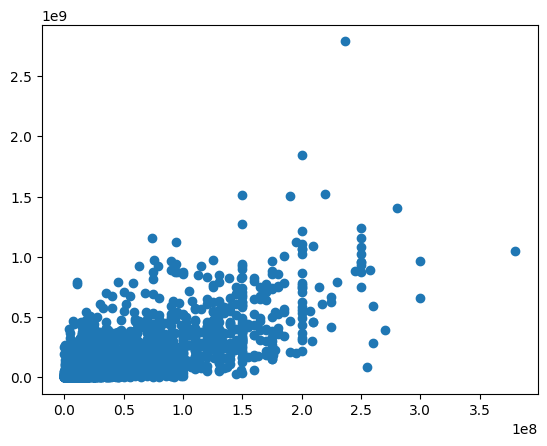

In [43]:
plt.scatter(X['budget'],y)

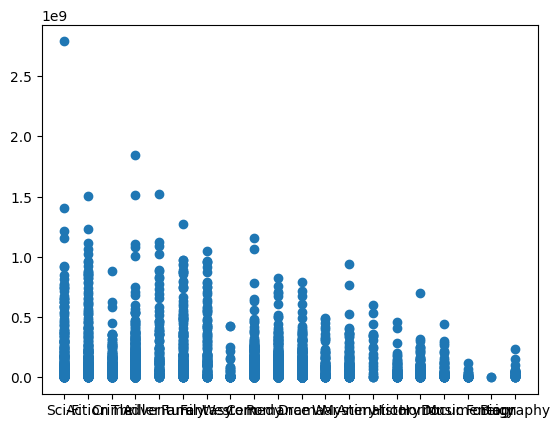

In [44]:
plt.scatter(X['genre'],y)

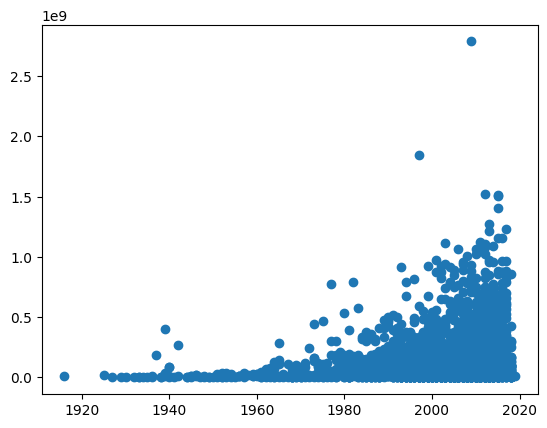

In [45]:
plt.scatter(X['year'],y)

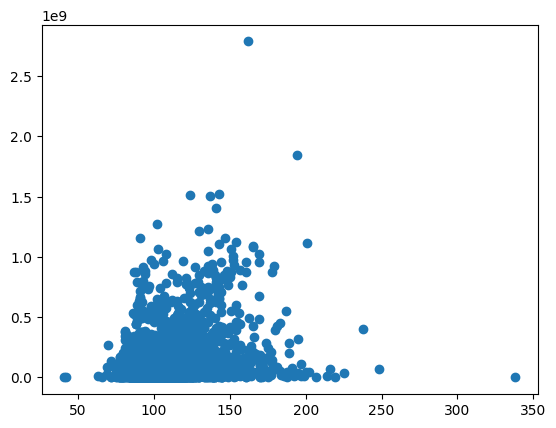

In [46]:
plt.scatter(X['runtime'],y)

C:\Users\Asus\AppData\Local\Temp\ipykernel_13864\1537544054.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['budget'])
C:\Users\Asus\AppData\Local\Temp\ipykernel_13864\1537544054.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['revenue'])


<Axes: xlabel='revenue', ylabel='Density'>

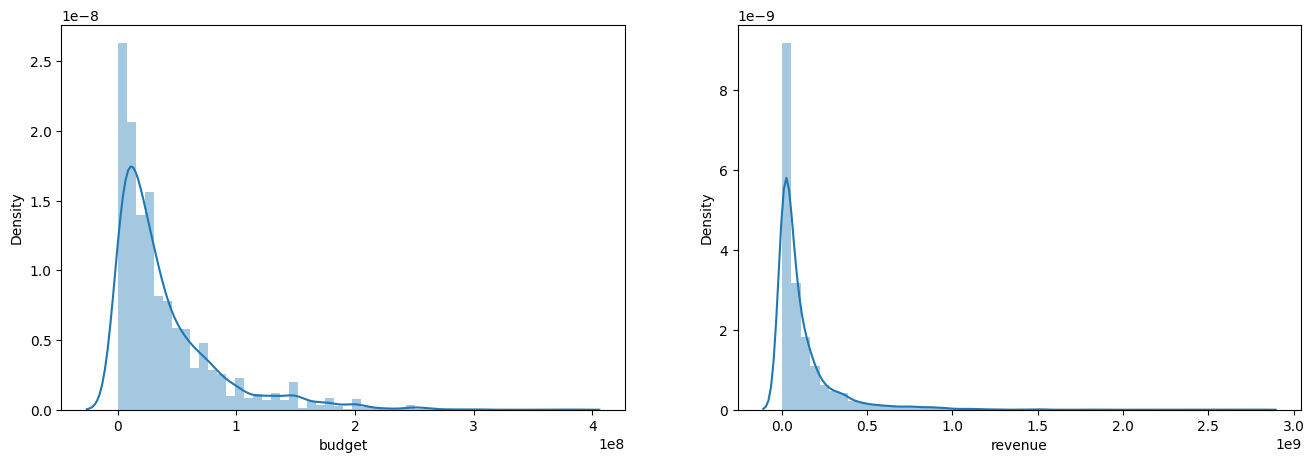

In [47]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['budget'])

plt.subplot(122)
sns.distplot(df['revenue'])

In [48]:
#finding the IQR -> learn the method

upper_limit = df['budget'].quantile(0.99)

In [49]:
upper_limit

np.float64(200000000.0)

In [50]:
df['budget'] = df['budget'].clip(upper=upper_limit)

C:\Users\Asus\AppData\Local\Temp\ipykernel_13864\1537544054.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['budget'])
C:\Users\Asus\AppData\Local\Temp\ipykernel_13864\1537544054.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['revenue'])


<Axes: xlabel='revenue', ylabel='Density'>

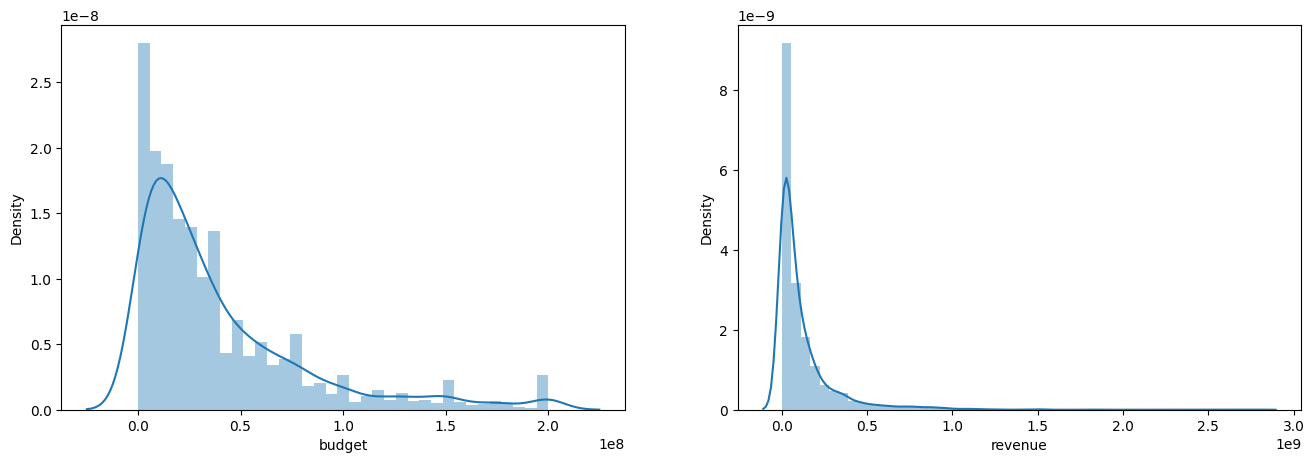

In [51]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['budget'])

plt.subplot(122)
sns.distplot(df['revenue'])

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [53]:
X_train

,genre,year,budget,runtime
4017,Romance,1995,2500000.0,105.0
2752,Sci-Fi,2015,15000000.0,108.0
2056,Thriller,2014,22000000.0,92.0
2560,Romance,1998,15000000.0,111.0
1777,Family,2009,26000000.0,91.0
...,...,...,...,...
1218,Comedy,2012,40000000.0,95.0
1418,Thriller,1997,35000000.0,155.0
913,Comedy,2008,70000000.0,104.0
5710,Horror,2015,100000.0,81.0


In [54]:
X_test

,genre,year,budget,runtime
424,Action,2010,80000000.0,103.0
3898,Romance,1958,3000000.0,108.0
4661,War,1925,245000.0,151.0
301,Sci-Fi,2012,102000000.0,172.0
2141,Drama,2008,20000000.0,128.0
...,...,...,...,...
1778,Comedy,2003,26000000.0,97.0
2533,Thriller,2012,17000000.0,95.0
707,Comedy,2005,60000000.0,94.0
2769,Romance,2006,13000000.0,120.0


In [55]:
y_train

4017      5535405.0
2752     36869414.0
2056     15447154.0
2560     46905889.0
1777    183293131.0
           ...     
1218     41863726.0
1418     25105255.0
913     225990978.0
5710     42964410.0
4582      1162014.0
Name: revenue, Length: 2917, dtype: float64

In [56]:
df['genre'].nunique()

20

In [57]:
#imputing transformers

preprocessing = ColumnTransformer([
    ('genre',OneHotEncoder(sparse_output=False, handle_unknown='ignore'),['genre']),
    ('scaling',StandardScaler(),['budget','runtime','year'])
    #we are not creating a new transformer from different as we have the transformation inside the data itself. 
],remainder='passthrough')

In [58]:
pipe = Pipeline([       #we have to pass a list of tuples to create a pipeline in the same order as we wanted to make connection b/w blocks
    ('preprocessing',preprocessing),    # The ColumnTransformer you just built # you dont need to write genre,genre and scaling,scaling in different tupples as u have created a new combined preprocessor 
    ('model',RandomForestRegressor(max_depth=5, min_samples_split=10, n_estimators=100))       # The machine learning model
])

In [59]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('genre', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [60]:
y_pred = pipe.predict(X_test)

In [61]:
y_pred1 = pipe.predict(X_train)

In [62]:
y_pred

array([1.80654146e+08, 1.85091153e+07, 1.83835569e+07, 3.18062319e+08,
       6.09737254e+07, 4.13009342e+08, 5.70887753e+08, 3.09453652e+07,
       3.50569576e+07, 2.79887603e+07, 1.38923052e+08, 4.05502196e+07,
       3.91991266e+07, 5.53593579e+07, 5.52874931e+07, 9.75258311e+07,
       5.45035843e+07, 9.08657821e+07, 1.59303991e+08, 2.32354235e+08,
       8.84504505e+07, 3.56781676e+07, 1.92664740e+08, 1.82298945e+08,
       4.58272728e+07, 6.66285026e+08, 1.01529699e+08, 1.53869944e+08,
       1.30678152e+08, 5.74819703e+07, 4.83358564e+08, 5.99505497e+07,
       2.54534005e+08, 1.80711224e+07, 1.26639448e+08, 6.09737254e+07,
       5.02845773e+07, 5.64797213e+07, 3.08739065e+07, 1.25768020e+08,
       5.64916955e+07, 1.16580774e+08, 5.51280808e+07, 5.68876373e+08,
       2.71848502e+07, 2.07493026e+07, 1.25768020e+08, 5.21966993e+08,
       3.57951780e+07, 5.39709674e+07, 3.18677330e+08, 4.98155682e+07,
       6.69463295e+07, 1.88723477e+08, 1.49217670e+08, 3.10419494e+08,
      

In [63]:
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [64]:
print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

R2 Score: 0.5490639980274665
MAE: 78408689.82410488
RMSE: 151614139.38564494


In [65]:
r2 = r2_score(y_train,y_pred1)

In [66]:
r2

0.6261042976884014

In [67]:
# Calculate both
train_score = pipe.score(X_train, y_train)
test_score = pipe.score(X_test, y_test)

print(f"Training R2: {train_score}")
print(f"Testing R2: {test_score}")

Training R2: 0.6261042976884014
Testing R2: 0.5490639980274665


since this results are close this means our model is learning rather than memorizing and now we are done!

In [68]:
import pickle

# Assuming 'pipe' is your full pipeline object that you trained
with open('Movie_Revenue_Predictor.pkl', 'wb') as file:
    pickle.dump(pipe, file)

In [69]:
unique_genres = df['genre'].unique()
print(unique_genres)


<StringArray>
[     'Sci-Fi',      'Action',       'Crime',    'Thriller',   'Adventure',
      'Family',     'Fantasy',     'Western',      'Comedy',     'Romance',
       'Drama',         'War',     'Mystery',   'Animation',     'History',
      'Horror',       'Music', 'Documentary',     'Foreign',   'Biography']
Length: 20, dtype: str
